In [71]:
import random
import numpy as np
from ipywidgets import interactive_output
from qiskit import QuantumCircuit, transpile
import seaborn as sns
from hamap.mapping import ha_mapping
from hamap import IBMQHardwareArchitecture
from contrib.random_graphs import create_coupling_graph
from qiskit.quantum_info import DensityMatrix, Statevector
from typing import Union

import networkx as nx
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Instruction, CircuitInstruction
from qiskit.quantum_info import Statevector
from qiskit.transpiler import CouplingMap, TranspileLayout


In [35]:

path = './data/nam_circs/barenco_tof_3.qasm'
qc = QuantumCircuit.from_qasm_file(path)

hardware = IBMQHardwareArchitecture('Star', num_nodes=qc.num_qubits)

perm = qc.qubits.copy()
random.shuffle(perm)
init = {q: i for i, q in enumerate(perm)}
init

{<Qubit register=(5, "q"), index=2>: 0,
 <Qubit register=(5, "q"), index=3>: 1,
 <Qubit register=(5, "q"), index=0>: 2,
 <Qubit register=(5, "q"), index=4>: 3,
 <Qubit register=(5, "q"), index=1>: 4}

In [69]:
from qiskit.transpiler.passes.routing import *
from qiskit.transpiler import CouplingMap, Layout


In [82]:
qc_out = transpile(qc, coupling_map=create_coupling_graph(hardware),
                   optimization_level=0, initial_layout=init
                   )
qc_out, final = ha_mapping(qc, init, hardware)


In [84]:
qc_out._layout = TranspileLayout(
    initial_layout=Layout(init),
    final_layout=Layout(final),
    input_qubit_mapping={q: i for i, q in enumerate(qc.qubits)},
    _input_qubit_count=qc.num_qubits,
    _output_qubit_list=qc.qubits
)

In [77]:
qc_out.layout

TranspileLayout(initial_layout=Layout({
0: <Qubit register=(5, "q"), index=2>,
1: <Qubit register=(5, "q"), index=3>,
2: <Qubit register=(5, "q"), index=0>,
3: <Qubit register=(5, "q"), index=4>,
4: <Qubit register=(5, "q"), index=1>
}), input_qubit_mapping={<Qubit register=(5, "q"), index=0>: 0, <Qubit register=(5, "q"), index=1>: 1, <Qubit register=(5, "q"), index=2>: 2, <Qubit register=(5, "q"), index=3>: 3, <Qubit register=(5, "q"), index=4>: 4}, final_layout=Layout({
1: <Qubit register=(5, "q"), index=2>,
2: <Qubit register=(5, "q"), index=3>,
0: <Qubit register=(5, "q"), index=0>,
3: <Qubit register=(5, "q"), index=4>,
4: <Qubit register=(5, "q"), index=1>
}), _input_qubit_count=5, _output_qubit_list=[<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>])

In [4]:
S1 = Statevector(qc).data
S2 = Statevector(qc_out).data
np.linalg.norm(S1 - S2)

3.581875008760223e-16

In [5]:
D1 = DensityMatrix(qc).data
D2 = DensityMatrix(qc_out).data

In [6]:
np.linalg.norm(D1 - D2)

3.862321986253138e-16

In [78]:
from qiskit import QuantumCircuit
from qiskit.transpiler import CouplingMap, Layout

def validate_circuit_with_swaps(circuit: QuantumCircuit, coupling_map: CouplingMap, initial_layout: Layout):
    layout = initial_layout.copy()
    for instr, qargs, _ in circuit.data:
        if instr.name == "swap":
            # q0 = layout[qargs[0]]
            # q1 = layout[qargs[1]]
            layout.swap(qargs[0], qargs[1])
            # 交换物理位置
            # layout[qargs[0]], layout[qargs[1]] = q1, q0
        elif instr.num_qubits == 2:
            phys0 = layout[qargs[0]]
            phys1 = layout[qargs[1]]
            if not coupling_map.graph.has_edge(phys0, phys1):
                print(f"❌ 非法双比特门：{instr.name}({phys0}, {phys1}) 不在耦合图中")
            else:
                print(f"✅ 合法双比特门：{instr.name}({phys0}, {phys1})")


In [80]:
layout = Layout()
layout.from_dict(final)

TranspileLayout(initial_layout=Layout({
0: <Qubit register=(5, "q"), index=2>,
1: <Qubit register=(5, "q"), index=3>,
2: <Qubit register=(5, "q"), index=0>,
3: <Qubit register=(5, "q"), index=4>,
4: <Qubit register=(5, "q"), index=1>
}), input_qubit_mapping={<Qubit register=(5, "q"), index=0>: 0, <Qubit register=(5, "q"), index=1>: 1, <Qubit register=(5, "q"), index=2>: 2, <Qubit register=(5, "q"), index=3>: 3, <Qubit register=(5, "q"), index=4>: 4}, final_layout=Layout({
1: <Qubit register=(5, "q"), index=2>,
2: <Qubit register=(5, "q"), index=3>,
0: <Qubit register=(5, "q"), index=0>,
3: <Qubit register=(5, "q"), index=4>,
4: <Qubit register=(5, "q"), index=1>
}), _input_qubit_count=5, _output_qubit_list=[<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>])

In [79]:
validate_circuit_with_swaps(qc_out, create_coupling_graph(hardware), layout)

❌ 非法双比特门：swap(2, 3) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(1, 2) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
❌ 非法双比特门：cx(1, 2) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
✅ 合法双比特门：cx(0, 2)
❌ 非法双比特门：cx(2, 1) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
❌ 非法双比特门：cx(2, 1) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
❌ 非法双比特门：cx(2, 1) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
❌ 非法双比特门：cx(2, 1) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(2, 4) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(3, 2) 不在耦合图中
❌ 非法双比特门：cx(1, 2) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
❌ 非法双比特门：cx(1, 2) 不在耦合图中
✅ 合法双比特门：cx(0, 2)
✅ 合法双比特门：swap(2, 0)
❌ 非法双比特门：

/var/folders/4d/fq7sssxx64s9kgphvvf_72lm0000gn/T/ipykernel_48965/2065173053.py:5: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in circuit.data:


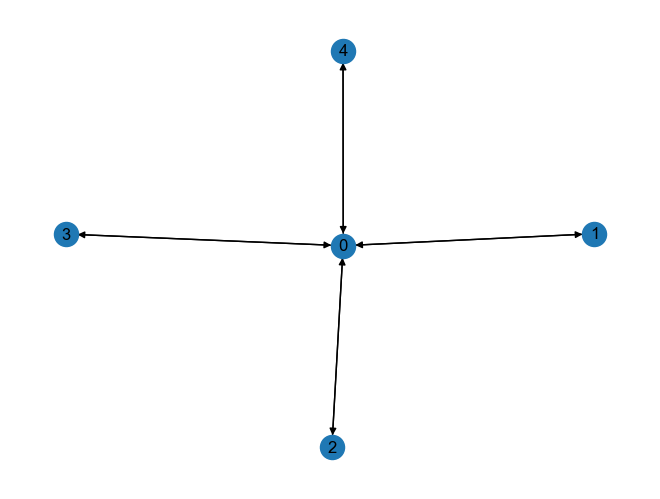

In [17]:
nx.draw(hardware, with_labels=True)


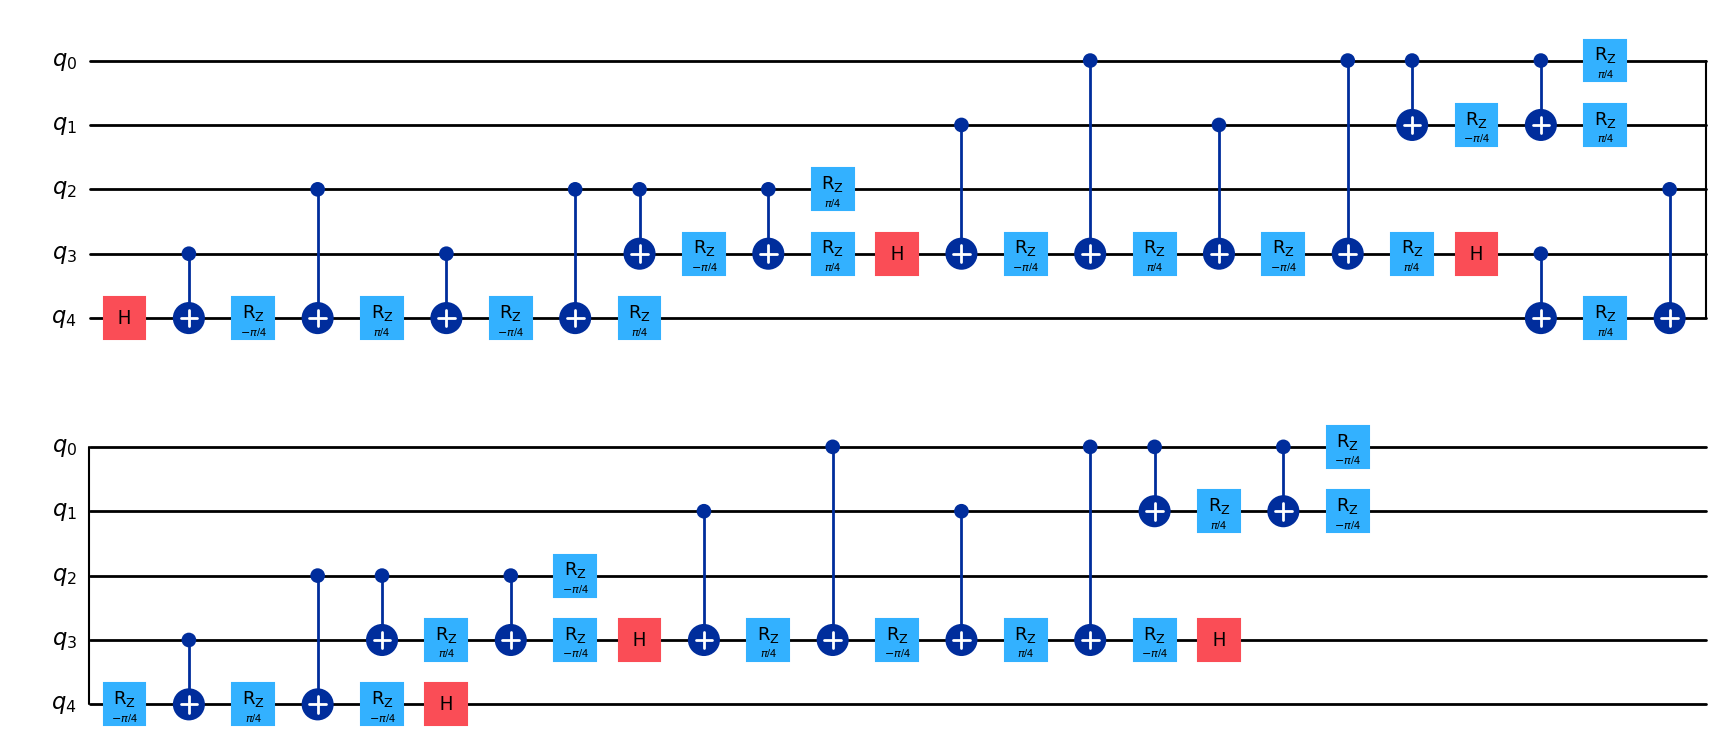

In [86]:
qc.draw("mpl")

In [87]:
init

{<Qubit register=(5, "q"), index=2>: 0,
 <Qubit register=(5, "q"), index=3>: 1,
 <Qubit register=(5, "q"), index=0>: 2,
 <Qubit register=(5, "q"), index=4>: 3,
 <Qubit register=(5, "q"), index=1>: 4}

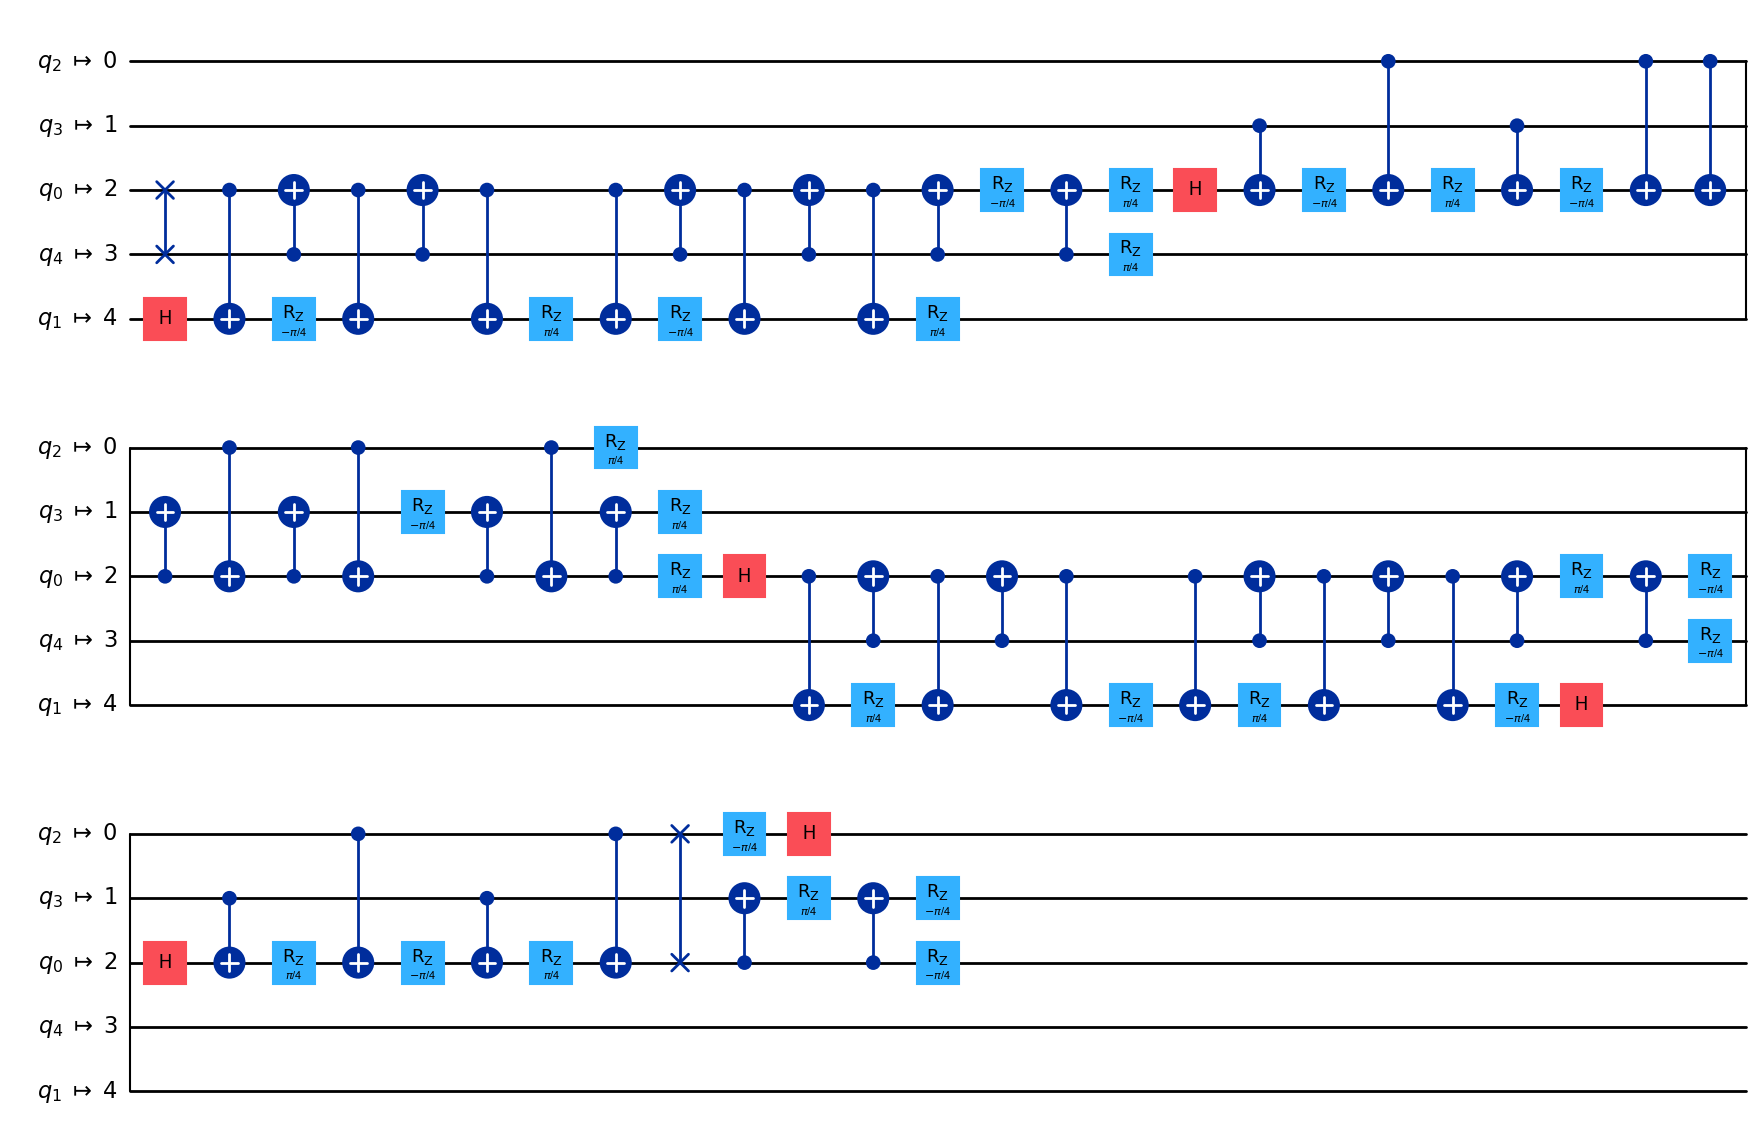

In [85]:
qc_out.draw("mpl")

In [89]:
for x in qc_out.data:
    print(x)

CircuitInstruction(operation=Instruction(name='swap', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=4>,), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=4>), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=2>), clbits=())
CircuitInstruction(operation=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[-0.7853981633974483]), qubits=(<Qubit register=(5, "q"), index=4>,), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), inde

In [102]:
from contrib.common import get_inverse_mapping


def verify_circuit_routed(qc: QuantumCircuit, graph: Union[CouplingMap, nx.Graph], initial_mapping):

    inverse_mapping = {qc.qubits[p]: q._index for q, p in init.items()}

    print(inverse_mapping)

    def has_edge(u, v):
        if isinstance(graph, CouplingMap):
            return graph.distance(u, v) == 1
        if isinstance(graph, nx.Graph):
            return graph.has_edge(u, v)
        raise TypeError(graph)

    for inst in qc.data: # type: CircuitInstruction
        qubits = inst.qubits
        if len(qubits) == 1:
            continue
        if len(qubits) == 2:
            u, v = qubits
            if not has_edge(inverse_mapping[u], inverse_mapping[v]):
                print(inverse_mapping[u], inverse_mapping[v])
                print('Error:', inst.operation.name, (u, v), 'not in edges')
                return False
            if inst.operation.name == 'swap':
                inverse_mapping[u], inverse_mapping[v] = inverse_mapping[v], inverse_mapping[u]
        else:
            print('Error: only 1 and 2 qubit ops are allowed', inst)
            return False

    return True

In [96]:
init

{<Qubit register=(5, "q"), index=2>: 0,
 <Qubit register=(5, "q"), index=3>: 1,
 <Qubit register=(5, "q"), index=0>: 2,
 <Qubit register=(5, "q"), index=4>: 3,
 <Qubit register=(5, "q"), index=1>: 4}

In [97]:
{qc.qubits[p]: q._index for q, p in init.items()}

{<Qubit register=(5, "q"), index=0>: 2,
 <Qubit register=(5, "q"), index=1>: 3,
 <Qubit register=(5, "q"), index=2>: 0,
 <Qubit register=(5, "q"), index=3>: 4,
 <Qubit register=(5, "q"), index=4>: 1}

In [103]:
verify_circuit_routed(qc_out, hardware, init)

{<Qubit register=(5, "q"), index=0>: 2, <Qubit register=(5, "q"), index=1>: 3, <Qubit register=(5, "q"), index=2>: 0, <Qubit register=(5, "q"), index=3>: 4, <Qubit register=(5, "q"), index=4>: 1}
4 1
Error: cx (<Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=4>) not in edges


False